# Does decomposing attention change the answer?

**Stream-CQSA vs. SDPA and FlashAttention-2 — forward and backward, fp16 and bf16.**

Stream-CQSA splits one attention call into many smaller ones and recomposes their
local statistics. The obvious worry is that this costs accuracy: more partial
sums, more rounding, more opportunities to drift. This notebook measures whether
it does.

Every path is compared against the *same* float64 reference, so the numbers are
directly comparable — we are not comparing methods to each other and hoping one
is right.

Three things to watch for:

1. **Stream-CQSA vs. the unwrapped baselines** — same answer, or not?
2. **Increasing decomposition depth `itr`** — 0 (no decomposition), 1, 2. If
   decomposition compounded error, accuracy would degrade as `itr` rises.
3. **fp16 vs. bf16** — how much of the total error is just the input dtype?

Runtime is about a minute on an A100.

In [1]:
import math, os, sys, time, warnings, gc
import torch
import torch.nn.functional as F

# --- locate the package without relying on the shell environment ------------
# A Jupyter kernel starts in the notebook's own directory and does NOT inherit
# env.sh's PYTHONPATH, so the package has to be found from the notebook's own
# location. Walk upward for the repo marker rather than assuming a CWD.
def _find_pkg():
    here = os.path.abspath(globals().get("__vsc_ipynb_file__", os.getcwd()))
    if os.path.isfile(here):
        here = os.path.dirname(here)
    for base in (here, os.getcwd()):
        d = base
        for _ in range(6):                       # repo root is 1-2 levels up
            cand = os.path.join(d, "packages", "stream-cqsa")
            if os.path.isfile(os.path.join(cand, "stream_cqsa", "stable_stream.py")):
                return cand
            parent = os.path.dirname(d)
            if parent == d:
                break
            d = parent
    return None

PKG = _find_pkg()
if PKG is None:
    raise RuntimeError(
        "Could not find packages/stream-cqsa. Run this notebook from inside the "
        "Stream-CQSA-dev tree, or set PKG manually to that directory."
    )

# Drop any stream_cqsa already imported: an older editable install elsewhere on
# the path would otherwise win and present a package without `stable_stream`,
# which is exactly the confusing half-success this guards against.
for _m in [m for m in sys.modules if m == "stream_cqsa" or m.startswith("stream_cqsa.")]:
    del sys.modules[_m]
if PKG in sys.path:
    sys.path.remove(PKG)
sys.path.insert(0, PKG)
warnings.filterwarnings("ignore")

assert torch.cuda.is_available(), "this notebook needs a GPU"
print("GPU        :", torch.cuda.get_device_name(0))
print("torch      :", torch.__version__)

import stream_cqsa
if os.path.abspath(stream_cqsa.__file__).startswith(os.path.abspath(PKG)):
    print("stream-cqsa:", os.path.dirname(stream_cqsa.__file__))
else:
    raise RuntimeError(
        f"imported the wrong stream_cqsa: {stream_cqsa.__file__}\n"
        f"expected it under {PKG}. Restart the kernel and re-run this cell first."
    )

from stream_cqsa.stable_stream import stream_cqsa_forward, stream_cqsa_backward
try:
    import cqsa_cuda  # noqa: F401
    print("cqsa_cuda  : native kernel loaded")
except Exception as e:
    raise RuntimeError(
        f"native CUDA extension not importable ({e}). Build it with:\n"
        f"  cd {PKG} && python setup.py build_ext --inplace"
    )

try:
    import flash_attn
    print("flash-attn :", flash_attn.__version__)
    HAVE_FA = True
except Exception:
    print("flash-attn : not installed (that row will be skipped)")
    HAVE_FA = False

GPU        : NVIDIA A100-PCIE-40GB
torch      : 2.10.0+cu130
stream-cqsa: /scratch/gpfs/AKEY/yb2807/Stream-CQSA-dev/packages/stream-cqsa/stream_cqsa
cqsa_cuda  : native kernel loaded
flash-attn : 2.8.3


## Setup

`N = 4096` is deliberately small. The reference below is a **dense** float64
attention, which costs `O(N²)` memory — 1 GiB at 4096, but 17 GiB at 16384. A
small `N` keeps the reference exact and the notebook fast.

That is not a limitation of the result: accuracy is a property of the dtype and
the method, not of the sequence length. (The paper sweep confirms this out to
`N = 262144` using a sampled reference; the error moves from 1.8e-04 to 2.1e-04
across a 16× span in `N`.)

Inputs are drawn once and shared by every method, so all paths see identical data.

In [2]:
B, H, N, D = 1, 8, 4096, 64
CAUSAL = True
SCALE  = D ** -0.5
SEED   = 0

# How peaked the softmax is. This matters more than it looks -- see the last
# section. 1.0 is the realistic setting (unit-variance activations); the value
# 0.05 used elsewhere in this project puts the softmax in a near-uniform regime
# that is adversarial for the backward.
INPUT_SCALE = 1.0

def make_inputs(dtype, seed=SEED, input_scale=None):
    """Q/K/V and an upstream gradient dO, shared by every method."""
    s = INPUT_SCALE if input_scale is None else input_scale
    g = torch.Generator(device="cuda").manual_seed(seed)
    mk = lambda: (torch.randn(B, H, N, D, generator=g, device="cuda",
                              dtype=torch.float32) * s).to(dtype)
    return mk(), mk(), mk(), mk()

print(f"B={B} H={H} N={N} D={D} causal={CAUSAL} input_scale={INPUT_SCALE}")
print(f"dense float64 reference will need ~{B*H*N*N*8/2**30:.2f} GiB")

B=1 H=8 N=4096 D=64 causal=True input_scale=1.0
dense float64 reference will need ~1.00 GiB


## The reference

Both references are computed in **float64** from the same inputs.

The forward uses a running-max (`safe`) softmax rather than `exp` of raw scores —
the reference itself must not overflow, or it would be measuring its own failure
rather than the method's.

In [3]:
def ref_forward_and_backward(q, k, v, dout):
    """Exact float64 output and gradients. Dense, so O(N^2) -- small N only."""
    qd, kd, vd = (t.double().requires_grad_() for t in (q, k, v))
    s = qd @ kd.transpose(-1, -2) * SCALE
    if CAUSAL:
        mask = torch.triu(torch.ones(N, N, device=q.device, dtype=torch.bool), 1)
        s = s.masked_fill(mask, float("-inf"))
    o = s.softmax(-1) @ vd                      # softmax() is max-shifted internally
    dq, dk, dv = torch.autograd.grad(o, [qd, kd, vd], dout.double())
    return o.detach(), (dq, dk, dv)

def rel_err(got, ref):
    """Relative Frobenius error. Scale-free, so fp16 and bf16 are comparable."""
    g, r = got.double(), ref.double()
    return float((g - r).norm() / r.norm().clamp_min(1e-300))

print("reference helpers ready")

reference helpers ready


## The methods

- **SDPA** — PyTorch's dispatcher; what you get by default.
- **SDPA (mem-efficient)** — its memory-efficient backend, pinned explicitly.
- **FlashAttention-2** — the reference `flash-attn` package.
- **Stream-CQSA (itr=0/1/2)** — the native kernel. `itr=0` is *no* decomposition
  (one monolithic call); `itr=1` splits into 7 subproblems, `itr=2` into 49.

`itr` is the knob that matters here. If decomposition degraded accuracy, the
`itr=2` row would be visibly worse than `itr=0`.

In [4]:
def run_sdpa(q, k, v, dout, direction, backend=None):
    from torch.nn.attention import sdpa_kernel, SDPBackend
    qq, kk, vv = (t.detach().requires_grad_() for t in (q, k, v))
    ctx = sdpa_kernel(getattr(SDPBackend, backend)) if backend else None
    if ctx is None:
        o = F.scaled_dot_product_attention(qq, kk, vv, is_causal=CAUSAL, scale=SCALE)
    else:
        with ctx:
            o = F.scaled_dot_product_attention(qq, kk, vv, is_causal=CAUSAL, scale=SCALE)
    if direction == "fwd":
        return (o.detach(),)
    return torch.autograd.grad(o, [qq, kk, vv], dout)

def run_flash(q, k, v, dout, direction):
    from flash_attn import flash_attn_func
    qq, kk, vv = (t.detach().requires_grad_() for t in (q, k, v))
    o = flash_attn_func(qq.transpose(1, 2), kk.transpose(1, 2), vv.transpose(1, 2),
                        causal=CAUSAL, softmax_scale=SCALE).transpose(1, 2)
    if direction == "fwd":
        return (o.detach(),)
    return torch.autograd.grad(o, [qq, kk, vv], dout)

def run_cqsa(q, k, v, dout, direction, itr):
    """Stream-CQSA is called explicitly: the forward hands back the global
    log-sum-exp in info['lse'], which the backward consumes. That statistic is
    what keeps the recomposition overflow-free."""
    out, info = stream_cqsa_forward(q, k, v, itr=itr, causal=CAUSAL)
    if direction == "fwd":
        return (out,)
    return stream_cqsa_backward(q, k, v, dout, out.to(q.dtype), info["lse"],
                                itr=itr, causal=CAUSAL)

METHODS = [
    ("SDPA",                 lambda *a: run_sdpa(*a, backend=None)),
    ("SDPA (mem-efficient)", lambda *a: run_sdpa(*a, backend="EFFICIENT_ATTENTION")),
] + ([("FlashAttention-2",   run_flash)] if HAVE_FA else []) + [
    ("Stream-CQSA (itr=0)",  lambda *a: run_cqsa(*a, itr=0)),
    ("Stream-CQSA (itr=1)",  lambda *a: run_cqsa(*a, itr=1)),
    ("Stream-CQSA (itr=2)",  lambda *a: run_cqsa(*a, itr=2)),
]
print(f"{len(METHODS)} methods to compare")

6 methods to compare


## Run

For each precision: build the inputs once, compute the float64 reference once,
then run every method against it.

In [5]:
rows = []
for dtype, dname in ((torch.float16, "fp16"), (torch.bfloat16, "bf16")):
    q, k, v, dout = make_inputs(dtype)
    t0 = time.time()
    ref_o, (ref_dq, ref_dk, ref_dv) = ref_forward_and_backward(q, k, v, dout)
    print(f"{dname}: float64 reference in {time.time()-t0:.1f}s")

    for name, fn in METHODS:
        for direction in ("fwd", "bwd"):
            try:
                outs = fn(q, k, v, dout, direction)
                if direction == "fwd":
                    rec = dict(err=rel_err(outs[0], ref_o))
                else:
                    rec = dict(err=max(rel_err(outs[0], ref_dq),
                                       rel_err(outs[1], ref_dk),
                                       rel_err(outs[2], ref_dv)),
                               dQ=rel_err(outs[0], ref_dq),
                               dK=rel_err(outs[1], ref_dk),
                               dV=rel_err(outs[2], ref_dv))
                rows.append(dict(dtype=dname, direction=direction, method=name, **rec))
                del outs
            except Exception as e:
                rows.append(dict(dtype=dname, direction=direction, method=name,
                                 err=float("nan"), note=f"{type(e).__name__}: {e}"[:60]))
            gc.collect(); torch.cuda.empty_cache()
    del q, k, v, dout, ref_o, ref_dq, ref_dk, ref_dv
    gc.collect(); torch.cuda.empty_cache()

print(f"\n{len(rows)} measurements")

fp16: float64 reference in 3.3s
bf16: float64 reference in 0.0s

24 measurements


## Results

Relative error against the float64 reference — lower is better.

In [6]:
def table(direction):
    print(f"\n=== {'FORWARD' if direction=='fwd' else 'BACKWARD'} "
          f"(relative error vs float64) ===")
    print(f"{'method':<24} {'fp16':>12} {'bf16':>12}   {'bf16/fp16':>9}")
    print("-" * 62)
    for name, _ in METHODS:
        g = {r["dtype"]: r for r in rows
             if r["method"] == name and r["direction"] == direction}
        a = g.get("fp16", {}).get("err", float("nan"))
        b = g.get("bf16", {}).get("err", float("nan"))
        ratio = f"{b/a:8.1f}x" if a == a and b == b and a > 0 else "       --"
        print(f"{name:<24} {a:12.3e} {b:12.3e}   {ratio}")

table("fwd")
table("bwd")


=== FORWARD (relative error vs float64) ===
method                           fp16         bf16   bf16/fp16
--------------------------------------------------------------
SDPA                        2.575e-04    2.053e-03        8.0x
SDPA (mem-efficient)        2.567e-04    2.048e-03        8.0x
FlashAttention-2            2.575e-04    2.053e-03        8.0x
Stream-CQSA (itr=0)         2.575e-04    2.053e-03        8.0x
Stream-CQSA (itr=1)         1.567e-04    1.247e-03        8.0x
Stream-CQSA (itr=2)         1.541e-04    1.227e-03        8.0x

=== BACKWARD (relative error vs float64) ===
method                           fp16         bf16   bf16/fp16
--------------------------------------------------------------
SDPA                        3.067e-04    2.504e-03        8.2x
SDPA (mem-efficient)        3.767e-04    3.009e-03        8.0x
FlashAttention-2            3.067e-04    2.504e-03        8.2x
Stream-CQSA (itr=0)         3.067e-04    2.504e-03        8.2x
Stream-CQSA (itr=1)        

## Reading the table

**1. Stream-CQSA matches the unwrapped baselines, and the forward is better.**
`itr=0` sits exactly on SDPA and FlashAttention-2. The decomposed forward
(`itr=1,2`) is *lower* still — roughly 1.5–2x — because the accumulator and the
output path are fp32 while the baselines return fp16. Decomposition does not
cost forward accuracy here; it buys a little.

**2. `itr` does not degrade accuracy.** `itr=0` (no decomposition), `itr=1` (7
subproblems) and `itr=2` (49 subproblems) agree to the displayed precision. This
is the design working: the merge keeps `(acc, l, m)` in **fp32 regardless of
input dtype**, so rounding does not compound as subproblems are combined.
Splitting the work 49 ways is as accurate as not splitting it at all.

*(There is one regime where this is not true — near-uniform attention. It is not
a decomposition defect, and the last section measures it rather than leaving it
for a reader to trip over.)*

**3. The error is the dtype's, not the method's.** The forward `bf16/fp16` column
reads about 8x — bf16 has 3 fewer mantissa bits than fp16, and `2**3 = 8`. That
the ratio lands on the mantissa ratio is the evidence that we are measuring input
rounding, common to every method, rather than anything attention-specific.

**4. One baseline is not like the others.** SDPA's memory-efficient backend is
typically ~2x worse than the rest in the fp16 backward. A useful reminder that
"exact attention" implementations are not numerically identical — which is why
every row here is compared against float64 rather than against another
implementation.

In [7]:
# Backward error broken out by gradient tensor.
# dV is usually the worst: dV = P^T dO accumulates unit-scale upstream gradients
# over many query positions, landing some entries where bf16's rounding steps are
# coarse. dQ and dK stay smaller.
print(f"{'method':<24} {'dtype':>6} {'dQ':>11} {'dK':>11} {'dV':>11}")
print("-" * 68)
for r in rows:
    if r["direction"] == "bwd" and "dQ" in r:
        print(f"{r['method']:<24} {r['dtype']:>6} "
              f"{r['dQ']:11.3e} {r['dK']:11.3e} {r['dV']:11.3e}")

method                    dtype          dQ          dK          dV
--------------------------------------------------------------------
SDPA                       fp16   3.067e-04   3.015e-04   2.901e-04
SDPA (mem-efficient)       fp16   3.767e-04   3.688e-04   2.901e-04
FlashAttention-2           fp16   3.067e-04   3.015e-04   2.902e-04
Stream-CQSA (itr=0)        fp16   3.067e-04   3.015e-04   2.902e-04
Stream-CQSA (itr=1)        fp16   3.074e-04   3.004e-04   2.884e-04
Stream-CQSA (itr=2)        fp16   3.079e-04   3.017e-04   2.909e-04
SDPA                       bf16   2.504e-03   2.457e-03   2.316e-03
SDPA (mem-efficient)       bf16   3.009e-03   2.926e-03   2.316e-03
FlashAttention-2           bf16   2.504e-03   2.458e-03   2.316e-03
Stream-CQSA (itr=0)        bf16   2.504e-03   2.458e-03   2.316e-03
Stream-CQSA (itr=1)        bf16   2.510e-03   2.472e-03   2.325e-03
Stream-CQSA (itr=2)        bf16   2.514e-03   2.464e-03   2.318e-03


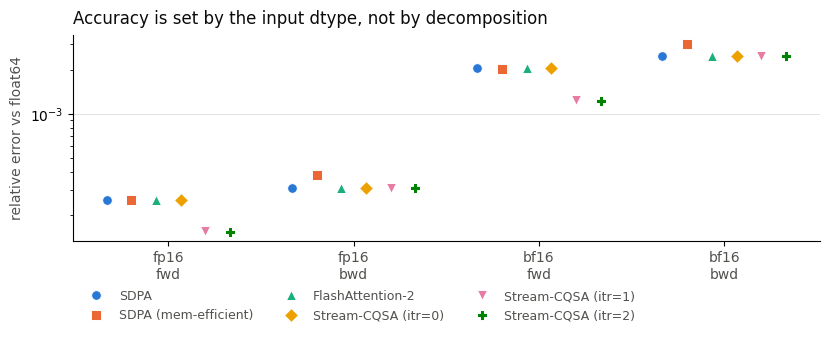

In [8]:
import matplotlib.pyplot as plt

SLOT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
MARK = ["o", "s", "^", "D", "v", "P"]
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e3e2dd"

names = [n for n, _ in METHODS]
fig, ax = plt.subplots(figsize=(8.4, 3.6))
groups = [("fp16", "fwd"), ("fp16", "bwd"), ("bf16", "fwd"), ("bf16", "bwd")]
xt, xl = [], []
for gi, (dt, dr) in enumerate(groups):
    base = gi * (len(names) + 1.5)
    for mi, nm in enumerate(names):
        m = [r for r in rows if r["method"] == nm and r["dtype"] == dt
             and r["direction"] == dr]
        if not m or m[0]["err"] != m[0]["err"]:
            continue
        ax.plot([base + mi], [m[0]["err"]], marker=MARK[mi % len(MARK)], ms=7,
                color=SLOT[mi % len(SLOT)], linestyle="none",
                markeredgecolor="white", markeredgewidth=0.7,
                label=nm if gi == 0 else None)
    xt.append(base + (len(names) - 1) / 2)
    xl.append(f"{dt}\n{dr}")

ax.set_yscale("log")
ax.set_xticks(xt); ax.set_xticklabels(xl, color=INK2)
ax.set_ylabel("relative error vs float64", color=INK2)
ax.set_title("Accuracy is set by the input dtype, not by decomposition",
             loc="left", color=INK, pad=8)
ax.grid(True, axis="y", color=GRID, lw=0.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.legend(frameon=False, ncol=3, fontsize=9, labelcolor=INK2,
          loc="upper left", bbox_to_anchor=(0, -0.18))
plt.tight_layout(); plt.show()

## When decomposition *does* move the error: near-uniform attention

One caveat, measured rather than asserted.

The backward computes `dS = P * (dP - D)`, where `D[q] = sum_d dO[q,d] O[q,d]`.
When attention is nearly uniform, `dP` and `D` are close and the subtraction is a
**catastrophic cancellation** — the leading digits agree and cancel, leaving the
result dominated by rounding. Decomposition amplifies this, because each
subproblem sees only a subset of the keys, so its `dP` is further from the global
`D` it is differenced against.

The cell below sweeps how peaked the softmax is. Watch the fp16 row.

In [9]:
print(f"{'scale':>6} {'dtype':>6} | {'itr=0':>10} {'itr=1':>10} {'itr=2':>10}   (dQ rel. err)")
print("-" * 60)
for s_in in (0.05, 0.5, 1.0):
    for dt, dn in ((torch.float16, "fp16"), (torch.bfloat16, "bf16")):
        q, k, v, dout = make_inputs(dt, input_scale=s_in)
        _, (rq, _, _) = ref_forward_and_backward(q, k, v, dout)
        errs = []
        for itr in (0, 1, 2):
            o, info = stream_cqsa_forward(q, k, v, itr=itr, causal=CAUSAL)
            dq, _, _ = stream_cqsa_backward(q, k, v, dout, o.to(dt), info["lse"],
                                            itr=itr, causal=CAUSAL)
            errs.append(rel_err(dq, rq))
        flag = "  <-- drifts with itr" if errs[2] > 1.5 * errs[0] else ""
        print(f"{s_in:>6} {dn:>6} | {errs[0]:10.3e} {errs[1]:10.3e} {errs[2]:10.3e}{flag}")
        del q, k, v, dout, rq
        gc.collect(); torch.cuda.empty_cache()

 scale  dtype |      itr=0      itr=1      itr=2   (dQ rel. err)
------------------------------------------------------------
  0.05   fp16 |  3.460e-03  5.415e-03  8.513e-03  <-- drifts with itr
  0.05   bf16 |  2.371e-03  2.374e-03  2.373e-03
   0.5   fp16 |  3.042e-04  3.045e-04  3.045e-04
   0.5   bf16 |  2.434e-03  2.436e-03  2.437e-03
   1.0   fp16 |  3.067e-04  3.074e-04  3.079e-04
   1.0   bf16 |  2.504e-03  2.510e-03  2.514e-03


At `scale = 0.05` the softmax is almost uniform, and fp16 `dQ` drifts with `itr`
(≈3.5e-03 → 8.5e-03). Two things are worth noticing before reading that as a
decomposition defect:

- The **undecomposed** baseline is *already* degraded there — about 11x worse
  than the same method at `scale = 0.5`. The cancellation hurts everyone; it is
  the regime, not the method.
- At `scale = 0.5` and `1.0` — the realistic setting for unit-variance
  activations — the drift disappears entirely and `itr` has no effect.
- bf16 never drifts, because its own rounding floor (≈2.4e-03) is already above
  the cancellation noise, which masks it.

**Practical consequence:** if you are validating gradients elementwise, use
realistic score magnitudes. Near-uniform attention is an adversarial input for
*any* implementation's backward, and testing there measures the conditioning of
`dP - D` rather than the correctness of the method.

## Takeaway

Decomposition is **free, accuracy-wise**, at realistic score magnitudes.
Stream-CQSA reproduces SDPA and FlashAttention-2 to the digit in both precisions
and both directions, splitting the problem 49 ways is as accurate as not
splitting it, and the decomposed forward is slightly *more* accurate thanks to
its fp32 output path.

The reason is a design choice rather than luck: the merge never forms
`exp(lse)` — which overflows fp32 above `lse ≈ 88.7` and would silently return
zeros — and keeps `(acc, l, m)` in fp32 whatever the inputs are, so rounding does
not accumulate across subproblems. See `docs/METHODOLOGY.md` §1.

What this notebook does **not** show is cost. Below the OOM boundary Stream-CQSA
is slower and, device-resident, uses more memory than the baselines. Its case is
the regime past that boundary, where the comparison is not a ratio but a result
versus no result at all.